In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm 

########## CONFIG 
INPUT_DIR = '/kaggle/input/datasets/zehrakucuker/brain-tumor-mri-images-classification-dataset/dataset' 
OUTPUT_IMG_DIR = '/kaggle/working/images'
OUTPUT_CSV = '/kaggle/working/brain_tumor_mri_metadata.csv'

# DataPreprocessing 
def prepare_dataset():
    os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
    metadata_list = []
    
    class_names = sorted([d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))])
    print(f"Found classes: {class_names}")
    for class_name in class_names:
        class_path = os.path.join(INPUT_DIR, class_name)
        img_list = sorted([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"\nProcessing {class_name}...")
        for i, img_name in enumerate(tqdm(img_list)):
            old_path = os.path.join(class_path, img_name)
            img = cv2.imread(old_path)
            if img is None:
                continue

            # increase contrast (0-100 => 1-99)
            p1, p99 = np.percentile(img, (1, 99))
            img_clipped = np.clip(img, p1, p99)
            img_contrast = cv2.normalize(img_clipped, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
            img_contrast = img_contrast.astype(np.uint8)
            
            #Augmentation 
            img_flipped = cv2.flip(img_contrast, 1)
            
            #save and making metadata
            new_img_name = f"{class_name}_{i:04d}.jpg"
            new_img_name_flip = f"{class_name}_{i:04d}_flip.jpg"
            
            new_path = os.path.join(OUTPUT_IMG_DIR, new_img_name)
            new_path_flip = os.path.join(OUTPUT_IMG_DIR, new_img_name_flip)
            
            cv2.imwrite(new_path, img_contrast)
            cv2.imwrite(new_path_flip, img_flipped)
            
            metadata_list.append({
                'filename': new_img_name,
                'class_label': class_name
            })
            metadata_list.append({
                'filename': new_img_name_flip,
                'class_label': class_name
            })
            
    df = pd.DataFrame(metadata_list)
    #One-hot
    df = pd.get_dummies(df, columns=['class_label'], dtype=int)
    df.columns = df.columns.str.replace('class_label_', '')
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df_shuffled.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSuccessfully processed and augmented {len(df_shuffled)} images.")
    return df_shuffled

# --- MAIN ---
if __name__ == "__main__":
    df_meta = prepare_dataset()
    print("\nMetadata Preview:")
    print(df_meta.head(15))

Found classes: ['glioma', 'healthy', 'meningioma', 'pituitary']

Processing glioma...


  0%|          | 0/3768 [00:00<?, ?it/s]


Processing healthy...


  0%|          | 0/3990 [00:00<?, ?it/s]


Processing meningioma...


  0%|          | 0/3806 [00:00<?, ?it/s]


Processing pituitary...


  0%|          | 0/4041 [00:00<?, ?it/s]


Successfully processed and augmented 31210 images.

Metadata Preview:
                  filename  glioma  healthy  meningioma  pituitary
0          glioma_3167.jpg       1        0           0          0
1    healthy_0107_flip.jpg       0        1           0          0
2          glioma_0546.jpg       1        0           0          0
3          glioma_3316.jpg       1        0           0          0
4  pituitary_1169_flip.jpg       0        0           0          1
5     glioma_0228_flip.jpg       1        0           0          0
6       pituitary_2736.jpg       0        0           0          1
7     glioma_3227_flip.jpg       1        0           0          0
8         healthy_3224.jpg       0        1           0          0
9       pituitary_1513.jpg       0        0           0          1


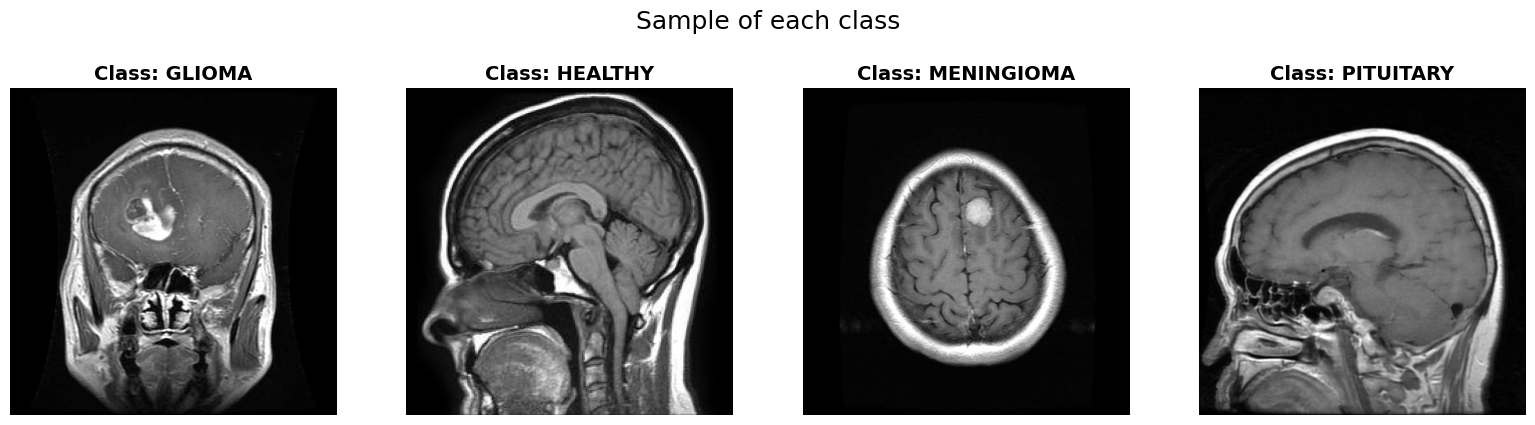

--------------------------------------------------


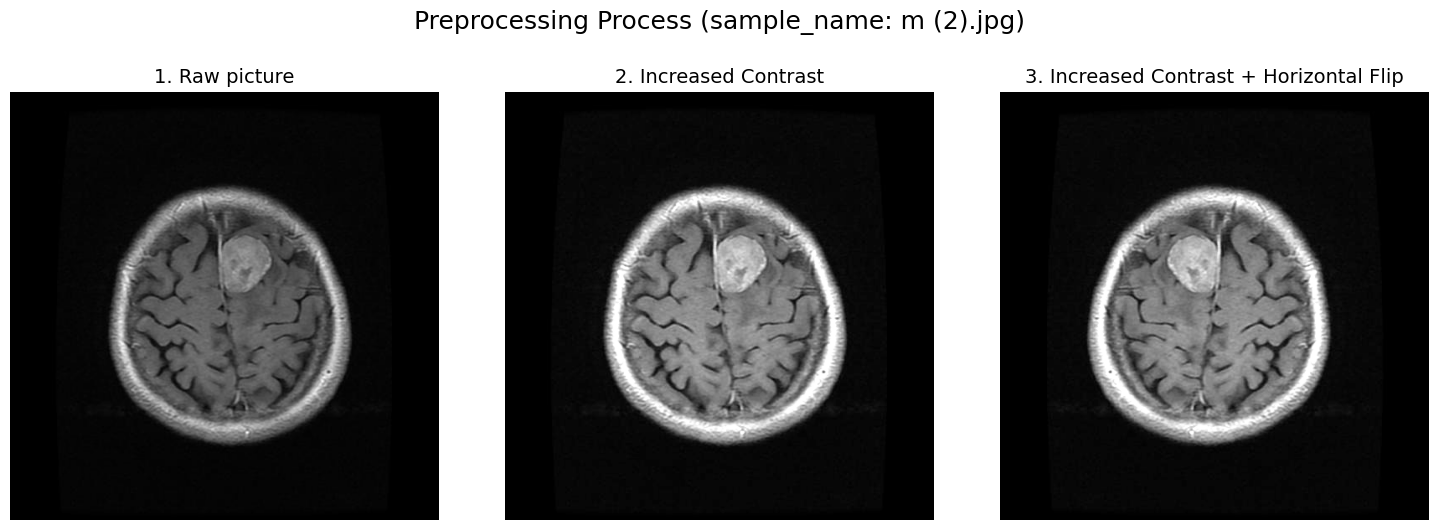

In [6]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_DIR = '/kaggle/input/datasets/zehrakucuker/brain-tumor-mri-images-classification-dataset/dataset' 
OUTPUT_IMG_DIR = '/kaggle/working/images'
OUTPUT_CSV = '/kaggle/working/brain_tumor_mri_metadata.csv'

def plot_class_samples():
    df = pd.read_csv(OUTPUT_CSV)
    classes = [col for col in df.columns if col != 'filename']
    plt.figure(figsize=(16, 4))
    for i, cls in enumerate(classes):
        sample_row = df[df[cls] == 1].sample(1).iloc[0]
        img_path = os.path.join(OUTPUT_IMG_DIR, sample_row['filename'])
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Class: {cls.upper()}", fontsize=14, fontweight='bold')
        plt.axis('off')
    plt.suptitle("Sample of each class", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

def plot_augmentation_demo():
    classes = [d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))]
    random_class = random.choice(classes)
    class_path = os.path.join(INPUT_DIR, random_class)
    img_name = random.choice([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png'))])
    old_path = os.path.join(class_path, img_name)
    
    img_original = cv2.imread(old_path)
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    
    p1, p99 = np.percentile(img_original, (1, 99))
    img_clipped = np.clip(img_original, p1, p99)
    img_contrast = cv2.normalize(img_clipped, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    img_contrast = img_contrast.astype(np.uint8)
    img_contrast_rgb = cv2.cvtColor(img_contrast, cv2.COLOR_BGR2RGB)
    
    img_flipped_rgb = cv2.flip(img_contrast_rgb, 1)

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_original_rgb)
    plt.title("1. Raw picture", fontsize=14)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_contrast_rgb)
    plt.title("2. Increased Contrast", fontsize=14)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_flipped_rgb)
    plt.title("3. Increased Contrast + Horizontal Flip", fontsize=14)
    plt.axis('off')
    
    plt.suptitle(f"Preprocessing Process (sample_name: {img_name})", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

# --- MAIN ---
if __name__ == "__main__":
    plot_class_samples()
    print("-" * 50)
    plot_augmentation_demo()